Initial data: info, description, and missing values
<class 'pandas.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   process_b1_capacity  2043 non-null   int64  
 1   process_b2_capacity  2043 non-null   int64  
 2   process_b3_capacity  2043 non-null   int64  
 3   process_b4_capacity  2043 non-null   int64  
 4   property_price       2043 non-null   int64  
 5   property_product     2043 non-null   int64  
 6   property_winner      2043 non-null   int64  
 7   verification_result  2043 non-null   bool   
 8   verification_time    2043 non-null   float64
dtypes: bool(1), float64(1), int64(7)
memory usage: 129.8 KB
None
        process_b1_capacity  process_b2_capacity  process_b3_capacity  \
count           2043.000000          2043.000000          2043.000000   
unique                  NaN                  NaN                  NaN   
top               

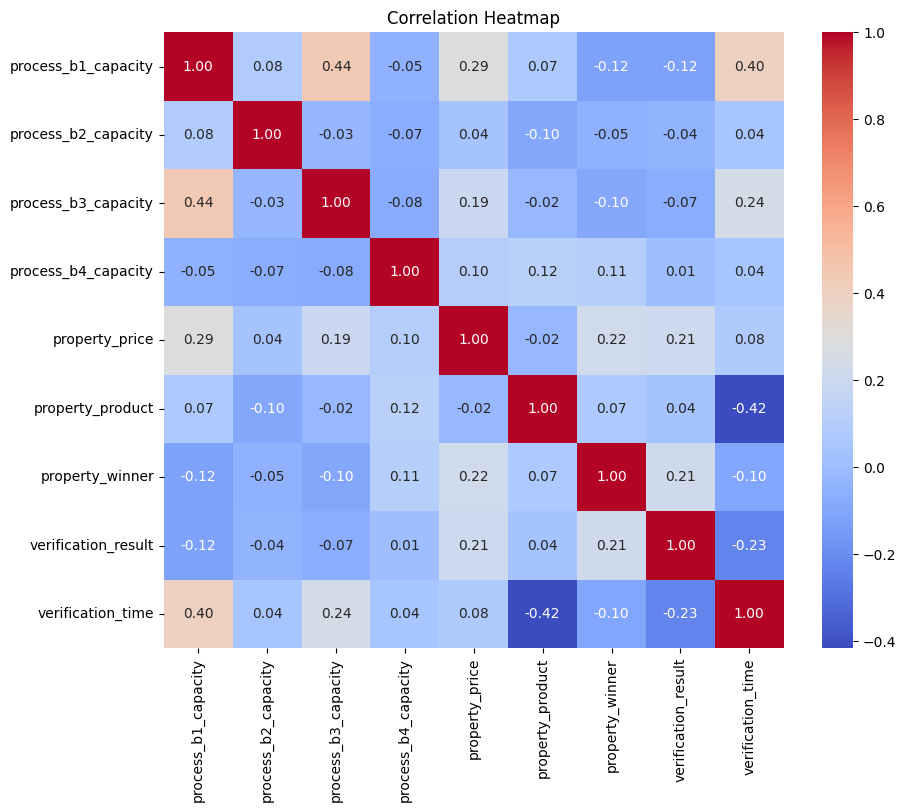


CROSS VALIDATION RESULTS:
Explained Variance per fold: [0.29715453 0.41502945 0.29063195 0.38128766 0.4499832  0.34752666
 0.46862991 0.36331815 0.50504938 0.38477445 0.41644658 0.39848844
 0.50395136 0.41965367 0.26752384]
Mean Explained Variance: 0.3939632818591167


In [ ]:
wercase + replace '.' with '_'
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(".", "_", regex=False)
)

# remove duplicates
df = df.drop_duplicates()

#Removed fixing types for verification_result, it was already int and thus unecessary
#
# 
#lo
  
#We dont need to handle missing values or impute anything, there are no missing values in the dataset.
#
#


#display the data:
print("Initial data: info, description, and missing values")
print(df.info())
print(df.describe(include="all"))
print(df.isnull().sum())

#3. EXPLORE & VISUALIZE **************************************************************

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#We dont need to treat int columns as categorical, 
# there are no categorical columns in the dataset. 
# We can just one-hot encode the binary columns, but they are already 0 and 1 so we can leave them as is.

# 4. PREPARE DATA FOR ML **************************************************************
#X and y
target = "verification_time"

#drop target from features and create X and y
#NOTE the model should not use verification_result, it may use this as a shortcut for predicting verification_time, 
#so we will drop it from the features.

#im pulling back in the final dataset on scaling, I dont think housing price is heavy enough to require it
#and initially it was done before splitting.

drop_cols = [target]
if "verification_result" in df.columns:
    drop_cols.append("verification_result")
    
X = df.drop(columns=drop_cols)
y = df[target]

#split the data into train, val, test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.10, random_state=0
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=2/9, random_state=0
)

# One-hot encode categorical variables
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns (important for consistency)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 5. SELECT AND TRAIN MODEL **************************************************************

linRegModel = LinearRegression()

#use 15 fold cross validation to evaluate the model on the training set
cv_results = cross_validate(
    linRegModel, 
    X_train, 
    y_train, 
    cv=15, 
    scoring = "explained_variance"
    )

print("\nCROSS VALIDATION RESULTS:")
print("Explained Variance per fold:", cv_results["test_score"])
print("Mean Explained Variance:", cv_results["test_score"].mean())

# Fit model
linRegModel.fit(X_train, y_train)


# VALIDATION RESULTS
y_val_pred = linRegModel.predict(X_val)

# FINAL TEST EVALUATION
y_test_pred = linRegModel.predict(X_test)

# RESIDUAL PLOT LATER
residuals = y_test - y_test_pred